# 군집 알고리즘

## 과일 사진 데이터 준비하기
- 사과, 바나나, 파인애플을 담고 있는 흑백사진 300장
- 넘파이 배열의 기본저장 포맷인 npy 파일로 저장

In [ ]:
# 코랩에서 fruits_300.npy  다운로드

!wget https://bit.ly/fruits_300 -O fruits_300.npy

# ! : 코랩은 이후 명령을 파이썬 코드가 아닌 리눅스 셀 명령으로 이해
# wget는 웹(Web)에서 파일을 다운로드하는 명령어
# --> -0 옵션을 사용하여 파일이름 지정

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 넘파이에서 npy 파일을 로드

fruits = np.load('fruits_300.npy')

In [ ]:
print(fruits.shape)

# (300, 100, 100)  : 갯수, 이미지 높이, 이미지 너비

(300, 100, 100)


In [ ]:
# 첫번째 이미지의 첫번째 행을 출력

print(fruits[0, 0, :])

# 각 값 : 0 ~ 255

In [ ]:
# 맷플롯립의 imshow() 함수를 사용하면 배열에 저장된 이미지를 출력
# 첫번째 이미지 : fruits[0]

plt.imshow(fruits[0], cmap='gray')
plt.show()

# 0에 가까울수록 검게, 높은값은 밝게

In [ ]:
# 바탕이 검게 나오므로 보기가 좋지 않네요
# cmap='gray_r' : 반전
# 밝은 부분이 0에 가깝고, 짙은 부분은 255에 가깝다

plt.imshow(fruits[0], cmap='gray_r')
plt.show()

In [ ]:
# 사과, 바나나, 파인애플 이미지 출력
# 각각 100 개씩 들어 있음

fig, axs = plt.subplots(1, 3)
axs[0].imshow(fruits[0], cmap='gray_r')
axs[1].imshow(fruits[100], cmap='gray_r')
axs[2].imshow(fruits[200], cmap='gray_r')
plt.show()

## 픽셀 값 분석하기

In [ ]:
# 이미지 하나 : 100*100
# 100*100 : 이미지를 펼쳐서 길이가 10,000 인 1차원 배열로 만듬
# -> 이미지로 출력하긴 어렵지만, 배열을 계산할 때 편리

apple = fruits[0:100].reshape(-1, 100*100)
pineapple = fruits[100:200].reshape(-1, 100*100)
banana = fruits[200:300].reshape(-1, 100*100)

In [ ]:
# 100개 이미지 : 하나의 이미지 배열
print(apple.shape)

In [ ]:
# 이미지별 픽셀의 평균값 계산
#  axis=1 : 두번째 축인 열을 따라 계산

print(apple.mean(axis=1))

#print(len(apple.mean(axis=1)))
# 첫번째이미지 픽셀 평균값, 두번째 이미지 픽셀 평균값

In [ ]:
# 각 샘플 100 개에 대한 평균값을 히스토그램으로 시각화

plt.hist(np.mean(apple, axis=1), alpha=0.8)
plt.hist(np.mean(pineapple, axis=1), alpha=0.8)
plt.hist(np.mean(banana, axis=1), alpha=0.8)

plt.legend(['apple', 'pineapple', 'banana'])  # 범례
plt.show()

# 바나나는 평균값이 40 아래에 집중되어 있다.
# 사과, 파인애플의 평균값은 90~100 사이에 집중

# 픽셀 평균값으로 바나나 / 사과, 파인애플 구분 가능
# -> 바나나는 사진에서 차지하는 영역이 작기 때문에 평균값도 작다

# 사과, 파인애플은 겹쳐있어서 픽셀값만으로는 구분하기 어렵다
# -> 대체로 형태로 동그랗고, 사진이 차지하는 크기도 비슷


In [ ]:
# 좀 더 나은 방법 ?
# -> 샘플의 평균값이 아니고 픽셀별 평균값을 비교
# -> 전체 샘플에 대한 각 픽셀의 평균을 계산
# -> 세 과일은 모양이 다르므로 픽셀값이 높은 위치가 조금 다를 것 같습니다.

# 픽셀 평균의 막대그래프 : 시간 조금 걸임

fig, axs = plt.subplots(1, 3, figsize=(20, 5))
axs[0].bar(range(10000), np.mean(apple, axis=0))
axs[1].bar(range(10000), np.mean(pineapple, axis=0))
axs[2].bar(range(10000), np.mean(banana, axis=0))
plt.show()

# 3개의 그래프를 보면 과일마다 값이 높은 구간이 다른다
# -> 사과는 사진 아래쪽으로 갈수록 값이 높아지고
# -> 파인애플은 비교적 고르면서 높다
# -> 바나나는 확실히 중아의 픽셀값이 높다

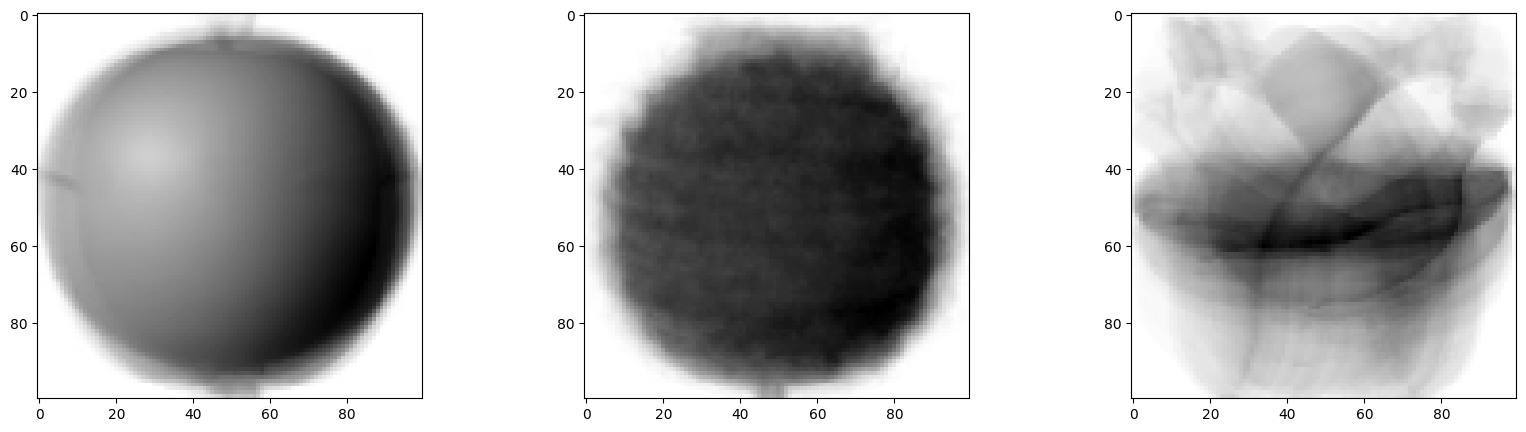

In [ ]:
# 평균 이미지 그리기

# 픽셀 평균값을 100*100 바꿔서 2차원 배열로 바꿔서 이미지처럼 출력
apple_mean = np.mean(apple, axis=0).reshape(100, 100)
pineapple_mean = np.mean(pineapple, axis=0).reshape(100, 100)
banana_mean = np.mean(banana, axis=0).reshape(100, 100)

# imshow() 함수를 사용하면 배열에 저장된 값을 이미지로 출력
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
axs[0].imshow(apple_mean, cmap='gray_r')
axs[1].imshow(pineapple_mean, cmap='gray_r')
axs[2].imshow(banana_mean, cmap='gray_r')
plt.show()

## 평균값과 가까운 사진 고르기

In [ ]:
# 위의 대표 이미지와 가까운 사진을 골라낸다면 사과, 파인애플, 바나나를 구분할 수 있지않을까요?

# 사과 사진의 평균값인  apple_mean과 가장 가까운 사진을 골라보죠.
# 절대값 오차 : fruits 배열에 있는 모든 샘플에서 apple_mean 을 뺀 절대값의 평균을 계산

abs_diff = np.abs(fruits - apple_mean)   # np.absoute() 다른 이름 / (300,100,100) 크기의 배열
abs_mean = np.mean(abs_diff, axis=(1,2)) # / (300,100,100) 크기의 배열
print(abs_mean.shape)  # abs_mean 은 각 샘플의 오차 평균이므로 (300, ) 인 1차원 배열
# print(abs_mean)

In [ ]:
# abs_mean과 오차가 가장 작은 샘플 100개를 골라보자
# np.argsort() 함수는 작은 것에서 큰 순서대로 나열한 abs_mean 배열의 인덱스를 반환한다.
# 이중에서 처음 100를 선택

apple_index = np.argsort(abs_mean)[:100]  # 오름차순 정렬 후 100개 선택

apple_index

In [ ]:
apple_index = np.argsort(abs_mean)[:100]  # 오름차순 정렬 후 100개 선택

# 10 * 10 격자로 이루어진 그래프를 그리자
fig, axs = plt.subplots(10, 10)  # figsize(8,6) 기본
for i in range(10):
    for j in range(10):
        axs[i, j].imshow(fruits[apple_index[i*10 + j]], cmap='gray_r')
        axs[i, j].axis('off')  # 깔끔한 이미지만 그리기 위해 좌표축을 그리지 않는다
plt.show()

## 확인문제

In [ ]:
# 바나나 100 개 출력



## k-mean 알고리즘
1. 무작위로 k개위 클러스터 중심을 정합니다.
2. 각 샘플에서 가장 가까운 클러스터 중심을 찾아 해당 클러스터의 샘플로 지정합니다.
3. 클러스터에 속한 샘플의 평균값으로 클러스터 중심을 변경합니다.
4. 클러스터 중심에 변화가 없을 때까지 2번으로 돌아가 반복합니다.

In [ ]:
# 자료 다운로드
!wget https://bit.ly/fruits_300 -O fruits_300.npy

In [3]:
# npy 파일을 읽어 넘파이 배열을 준비
# 훈련을 위해 ( 샘플개수, 너비, 높이 ) --> ( 샘플개수, 너비*높이 ) 2차원을 변경

import numpy as np

fruits = np.load('fruits_300.npy')
fruits_2d = fruits.reshape(-1, 100*100)

In [14]:
# k-평균 알고리즘은 KMeans 클래스에 구현되어 있음
# n_clusters 속성 : 클러스터의 갯수 지정

from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, random_state=42)  # 객체 생성
km.fit(fruits_2d)    # 훈련

KMeans(n_clusters=3, random_state=42)

In [15]:
# 다른 클래스 사용법과 비슷하나, 비지도학습이므로 fit() 메소드에 타깃데이터를 사용하지 않는다

print(km.labels_)

# print( len(km.labels_) )

[2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 0 2 0 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 0 0 2 2 2 2 2 2 2 2 0 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1]


In [16]:
# 레이블 0,1,2로 모은 샘플의 갯수를 확인

print(np.unique(km.labels_, return_counts=True))

(array([0, 1, 2], dtype=int32), array([112,  98,  90]))


In [17]:
# 각 클러스터가 어떤 이미지를 나타냈는지 그림으로 출력
# draw_fruits() 함수 :
# ceil() 함수 : 올림함수

import matplotlib.pyplot as plt

def draw_fruits(arr, ratio=1):
    n = len(arr)     # n은 샘플 개수입니다

    # 한 줄에 10개씩 이미지를 그립니다. 샘플 개수를 10으로 나누어 전체 행 개수를 계산합니다.
    rows = int(np.ceil(n/10))

    # 행이 1개 이면 열 개수는 샘플 개수입니다. 그렇지 않으면 10개입니다.
    cols = n if rows < 2 else 10
    fig, axs = plt.subplots(rows, cols,
                            figsize=(cols*ratio, rows*ratio))
                            # 피겨사이즈 조절
    for i in range(rows):
        for j in range(cols):
            if i*10 + j < n:      # n 개까지만 그립니다.
                axs[i, j].imshow(arr[i*10 + j], cmap='gray_r')
            axs[i, j].axis('off')  # 깔끔한 이미지만 그리기 위해 좌표축을 그리지 않는다
    plt.show()


In [ ]:
# 함수 호출 : 0, 1, 2
draw_fruits(fruits[km.labels_== 2])

##최적의 k 찾기
- 어떻게 하면 적절한 k를 찾을 수 있을까?
- 적절한 클러스터 개수 찾는 방법 : 엘보우 방법

In [ ]:
# inertia 이너셔 : 클러스터 중심과 클러스터에 속한 샘플 사이의 거리의 제곱합
# 클러스터 갯수를 증가하면서 이너셔를 그래프로 그리면 이너셔가 감소하는 꺽이는 지점!
# -> 클러스터를 늘려도 밀집도가 개선되지 않는다.
# -> 이지점이 마치 팔꿈치 모양이어서 엘보우 방법이라 한다.
# -> k=3 에서 기울기가 조금 바뀐다. 이 지점이 최적의 k

inertia = []
for k in range(2, 7):  # 임의로 2~6까지 지정해 보자
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(fruits_2d)
    inertia.append(km.inertia_)

plt.plot(range(2, 7), inertia)
plt.show()